In [63]:
# Read the RC parameters from a data sheet of an excel file

import pandas as pd

def read_rc_parameters(file_path, sheet_name=None, hasHeader=True):
    # Read a data sheet of an excel file
    df = pd.read_excel(file_path, sheet_name=sheet_name)

    # Extract the parameters into a dictionary
    rc_parameters = {}
    
    coefficient_names = ['R0', 'R1', 'R2', 'C0', 'C1', 'C2', 'Voc']  # Example coefficient names, adjust as needed
    for name in coefficient_names:
        if name in df.columns:
            start = 0 if hasHeader else 1  # If there's a header, start from the first row; otherwise, start from the second row
            # read the first five parameters in this column
            rc_parameters[name] = df[name].values[start:start+5]  # Assuming the parameters are in the first five rows after the header

    return rc_parameters

In [64]:
# Define the ODEs for the 2nd-order RC circuit, where RC parameters are functions of SOC
import numpy as np

EPS = 1e-9

def _safe_polyval(coeffs, soc, min_value=None):
    soc_clipped = np.clip(soc, 0.0, 1.0)
    value = np.polyval(np.asarray(coeffs, dtype=float), soc_clipped)
    value = np.nan_to_num(value, nan=min_value if min_value is not None else 0.0, posinf=1e6, neginf=0.0)
    if min_value is not None:
        # output the invalid parameter values for debugging purposes
        # invalid_mask = value < min_value
        # if np.any(invalid_mask):
        #     print(f"Warning: Found {np.sum(invalid_mask)} parameter values below the minimum threshold of {min_value}. Clipping to minimum value.")
        value = np.maximum(value, min_value)
    return value


def second_order_rc_circuit_odes(t, y, I_batt, C_cap, rc_params):
    """
    Defines the system of ODEs for a RC equivalent circuit.
    y[0] represents Voltage across C1 (V_th)
    y[1] represents Voltage across C2 (V_th2)
    y[2] represents State of Charge (SOC)
    """
    V_th, V_th2, SOC = y

    # Keep SOC in physical range to avoid extrapolation blow-ups.
    SOC = np.clip(SOC, 0.0, 1.0)

    # Evaluate RC parameters safely.
    R_1 = _safe_polyval(rc_params['R1'], SOC, min_value=EPS)
    R_2 = _safe_polyval(rc_params['R2'], SOC, min_value=EPS)
    C_1 = _safe_polyval(rc_params['C1'], SOC, min_value=EPS)
    C_2 = _safe_polyval(rc_params['C2'], SOC, min_value=EPS)

    # Define the ODEs based on the RC circuit equations.
    dV_th_dt = I_batt / C_1 - V_th / (R_1 * C_1)
    dV_th2_dt = (V_th - V_th2) / (R_2 * C_2)
    dSOC_dt = -I_batt / (3600 * max(C_cap, EPS))

    return [dV_th_dt, dV_th2_dt, dSOC_dt]

In [65]:
# Define the first-order RC circuit ODEs for comparison
def first_order_rc_circuit_odes(t, y, I_batt, C_cap, rc_params):
    """
    Defines the system of ODEs for a first-order RC equivalent circuit.
    y[0] represents Voltage across C1 (V_th)
    y[1] represents State of Charge (SOC)
    """
    V_th, SOC = y

    SOC = np.clip(SOC, 0.0, 1.0)

    # Evaluate RC parameters safely.
    R_1 = _safe_polyval(rc_params['R1'], SOC, min_value=EPS)
    C_1 = _safe_polyval(rc_params['C1'], SOC, min_value=EPS)

    # Define the ODEs based on the RC circuit equations.
    dV_th_dt = I_batt / C_1 - V_th / (R_1 * C_1)
    dSOC_dt = -I_batt / (3600 * max(C_cap, EPS))

    return [dV_th_dt, dSOC_dt]

In [66]:
# fitting coefficients for R_total, found in [[zhang2024PerformanceInvestigation]]
co_soc = [46.19, -97.2, -195.2, 1070, -1368, 568.2]  # Example coefficients for SOC terms, adjust as needed
co_temp = [-0.46, 1.726, -2.423, 0.6427, 0.3572]  # Example coefficients for temperature terms, adjust as needed

# A fitting function for R_total, found in [[zhang2024PerformanceInvestigation]]

def R_total_fitting_function(soc, T, co_soc=co_soc, co_temp=co_temp):
    
    R_tot = co_soc[0] + co_soc[1] * soc + co_temp[0]*T \
            + co_soc[2] * soc**2 + co_temp[1]*soc*T \
            + co_soc[3] * soc**3 + co_temp[2]*soc**2*T \
            + co_soc[4] * soc**4 + co_temp[3]*soc**3*T \
            + co_soc[5] * soc**5 + co_temp[4]*soc**4*T 
    return R_tot * 1e-3 # Convert from mOhm to Ohm

In [67]:
# Example usage
import os
file_path = os.path.join(os.curdir, "data", r"MD05E070290A1  OUT table_Param_identified_Liu__MD05E070204A2.xlsx")  # Path to your Excel file
print(f"Reading RC parameters from file: {file_path}")
# sheet_name = 'vespaiboon2024AnalyzingComputat'  # Name of the sheet containing the parameters
# sheet_name = 'Xin'  # Name of the sheet containing the parameters
# the name list of the sheet containing the parameters

sheet_names = ['vespaiboon2024AnalyzingComputat', 'Liu', 'Matlab', 'Xin']  # List of sheet names to try
circuit_types = [second_order_rc_circuit_odes, first_order_rc_circuit_odes, second_order_rc_circuit_odes, second_order_rc_circuit_odes]  # List of circuit types corresponding to the sheet names, adjust as needed

# Try reading parameters from each and save them in a dictionary

rc_params_dict = {}
for sheet_name, circuit_type in zip(sheet_names, circuit_types):
    try:
        rc_params = read_rc_parameters(file_path, sheet_name)
        rc_params_dict[sheet_name] = (rc_params, circuit_type)  # Store both the parameters and the circuit type in the dictionary
        print(f"Successfully read parameters from sheet '{sheet_name}'")
    except Exception as e:
        print(f"Failed to read parameters from sheet '{sheet_name}': {e}")


rc_params = read_rc_parameters(file_path, sheet_names[0])
print(rc_params)
print(rc_params['R0'])  # Print the R0 parameters to verify

Reading RC parameters from file: .\data\MD05E070290A1  OUT table_Param_identified_Liu__MD05E070204A2.xlsx
Successfully read parameters from sheet 'vespaiboon2024AnalyzingComputat'
Successfully read parameters from sheet 'Liu'
Successfully read parameters from sheet 'Matlab'
Successfully read parameters from sheet 'Xin'
{'R0': array([0.023, 0.   , 0.   , 0.   , 0.   ]), 'R1': array([0.0465, 0.    , 0.    , 0.    , 0.    ]), 'R2': array([0.01, 0.  , 0.  , 0.  , 0.  ]), 'C1': array([1850,    0,    0,    0,    0]), 'C2': array([1.52, 0.  , 0.  , 0.  , 0.  ]), 'Voc': array([  2.931648,   6.045809, -24.97768 ,  51.46373 , -47.9203  ])}
[0.023 0.    0.    0.    0.   ]


In [ ]:
# Calculate the RC parameters using the extracted coefficients
# The R, C parameters are the functions of the coefficients and the state of charge (SOC)
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import os.path
import pandas as pd


# The state of charge (SOC) is a function of time, which can be calculated from the current and the capacity
C_cap = 2.9  # Battery capacity in Ah
C_rate = 3.0  # C rate
# Simulation parameters
SOC_init = 1.0  # starting State of Charge (fully charged)
Vth_init = 0.0  # initial Thevenin voltage
Vth2_init = 0.0 # initial Thevenin voltage across C2
I_batt = C_cap * C_rate  # Constant discharge current in A
T_batt_init = 25.0   # Battery temperature in Celsius
end_time = C_cap / I_batt * 3600  # in seconds
t_span = (0, end_time)  # Time span for the simulation
num_steps = 500
t_eval = np.linspace(*t_span, num_steps) # Points at which to store the solution

H_batt = 65 * 1e-3 # in m, battery height, found in [[zhang2024PerformanceInvestigation]]
D_batt = 18 * 1e-3 # in m, battery diameter, found in [[zhang2024PerformanceInvestigation]]
A_batt = np.pi * D_batt * H_batt  # in m^2, surface area of the battery, calculated based on the height and diameter
V_batt = np.pi * (D_batt / 2)**2 * H_batt  # in m^3, volume of the battery, calculated based on the height and diameter

# mass and specific heat capacity of the battery
mass_battery = 47 * 1e-3  # in kg, found in [[zhang2024PerformanceInvestigation]]
cp_battery = 877.24  # in J/kg-K, found in [[zhang2024PerformanceInvestigation]]

solver = ['LSODA', 'RK45', 'BDF'][2]

# solutions dictionary to store the results for each sheet
solutions = {}

for sheet_name, (rc_params, circuit_type) in rc_params_dict.items():
    # if sheet_name == 'Liu':
        # continue # Skip the first-order parameter set in this notebook flow

    print(f"Solving ODEs for sheet: {sheet_name} using solver: {solver}, circuit type: {circuit_type.__name__}")

    y0 = [Vth_init, Vth2_init, SOC_init] if circuit_type == second_order_rc_circuit_odes else [Vth_init, SOC_init]

    # Solve the ODE
    solution = solve_ivp(
        circuit_type,
        t_span,
        y0,
        args=(I_batt, C_cap, rc_params),
        t_eval=t_eval,
        method=solver
    )

    if not solution.success:
        print(f"Skipping sheet '{sheet_name}' due to solver failure: {solution.message}")
        continue

    soc_calc = solution.y[2] if circuit_type == second_order_rc_circuit_odes else solution.y[1]
    soc_calc = np.clip(np.nan_to_num(soc_calc, nan=0.0, posinf=1.0, neginf=0.0), 0.0, 1.0)

    # calculate the resistance and capacitance values at each time step based on the SOC values
    R_0_values = _safe_polyval(rc_params['R0'], soc_calc, min_value=EPS)
    R_1_values = _safe_polyval(rc_params['R1'], soc_calc, min_value=EPS)
    C_1_values = _safe_polyval(rc_params['C1'], soc_calc, min_value=EPS)

    R_2_values = _safe_polyval(rc_params['R2'], soc_calc, min_value=EPS) if circuit_type == second_order_rc_circuit_odes else np.zeros_like(soc_calc)
    C_2_values = _safe_polyval(rc_params['C2'], soc_calc, min_value=EPS) if circuit_type == second_order_rc_circuit_odes else np.zeros_like(soc_calc)

    # Compare the heat generation calculated from the fitted R_total and the heat generation calculated from the sum of R_0, R_1, and R_2    
    
    n_steps = len(t_eval)
    
    q_ohmic_arr = np.zeros(n_steps)
    q_pol1_arr = np.zeros(n_steps)
    q_pol2_arr = np.zeros(n_steps)
    q_gen_arr = np.zeros(n_steps)  
    q_gen_arr_total = np.zeros(n_steps)  
    T_arr = np.zeros(n_steps)
    T = T_batt_init
    V1 = 0.0
    V2 = 0.0
    
    dt = t_eval[1] - t_eval[0]  # Time step size    
    I = I_batt  # Assuming constant current for simplicity, can be modified to be a function of time if needed
    
    for k in range(n_steps):
        t_start = t_eval[k]
        t_end = t_eval[k] + dt
        
        soc = soc_calc[k]
        R_0 = R_0_values[k]
        R_1 = R_1_values[k]
        R_2 = R_2_values[k]
        C_1 = C_1_values[k]
        C_2 = C_2_values[k]
        R_total = R_0 + R_1 + R_2
        
        tau1 = max(R_1 * C_1, EPS)
        tau2 = max(R_2 * C_2, EPS) if circuit_type == second_order_rc_circuit_odes else 0.0
        
        a1 = np.exp(-dt / tau1) if tau1 > EPS else 0.0
        a2 = np.exp(-dt / tau2) if tau2 > EPS else 0.0
        
        V1 = I_batt * R_1 * (1 - a1) if tau1 > EPS else 0.0
        V2 = I_batt * R_2 * (1 - a2) if tau2 > EPS else 0.0 
        
        # 生热功率
        q_ohmic = I**2 * R_0
        q_pol1 = I * V1  # I^2 R_1  V_1 <= R_1 * I 
        q_pol2 = I * V2
        q_gen = q_ohmic + q_pol1 + q_pol2
        q_gen_total = I**2 * R_total

        q_ohmic_arr[k] = q_ohmic
        q_pol1_arr[k] = q_pol1
        q_pol2_arr[k] = q_pol2
        q_gen_arr[k] = q_gen
        q_gen_arr_total[k] = q_gen_total

        # 最后一个点不再更新
        if k == n_steps - 1:
            break

        # ===== 2RC 状态更新 =====
        tau1 = max(R_1 * C_1, EPS)
        tau2 = max(R_2 * C_2, EPS) if circuit_type == second_order_rc_circuit_odes else 0.0

        # 解析离散
        a1 = np.exp(-dt / tau1)
        a2 = np.exp(-dt / tau2)

        V1 = a1 * V1 + R_1 * (1.0 - a1) * I
        V2 = a2 * V2 + R_2 * (1.0 - a2) * I

        # ===== 温度更新 =====
        q_cooling = 0 # - hA * (T - t_amb_c)
        
        dTdt = (q_gen - q_cooling) / (mass_battery * cp_battery)
        T = T + dTdt * dt
        T_arr[k] = T

        # ===== SOC 更新 =====
        soc = soc - I * dt / (C_cap * 3600.0)
        # soc = max(soc, soc_end)        
      

    # Store the solution in the dictionary
    solutions[sheet_name] = {
        'time': solution.t,
        'V_th': solution.y[0],
        'V_th2': solution.y[1] if circuit_type == second_order_rc_circuit_odes else np.zeros_like(solution.y[0]),
        'SOC': soc_calc,
        'R_0': R_0_values,
        'R_1': R_1_values,
        'R_2': R_2_values,
        'C_1': C_1_values,
        'C_2': C_2_values,
        'heat_generation': q_gen_arr,
        'heat_generation_total': q_gen_arr_total,
        'R_total': R_total,        
        # 'heat_generation_Zhang': heat_generation_Zhang,
        'T_batt_over_time': T_arr,
        # 'temperature_rise': temperature_rise,              
    }

print(f"Completed simulations for {len(solutions)} sheet(s).")

Solving ODEs for sheet: vespaiboon2024AnalyzingComputat using solver: BDF, circuit type: second_order_rc_circuit_odes
Solving ODEs for sheet: Liu using solver: BDF, circuit type: first_order_rc_circuit_odes
Solving ODEs for sheet: Matlab using solver: BDF, circuit type: second_order_rc_circuit_odes
Solving ODEs for sheet: Xin using solver: BDF, circuit type: second_order_rc_circuit_odes
Completed simulations for 4 sheet(s).


C:\Users\admin\AppData\Local\Temp\ipykernel_33084\2589545374.py:132: RuntimeWarning: divide by zero encountered in scalar divide
  a2 = np.exp(-dt / tau2)


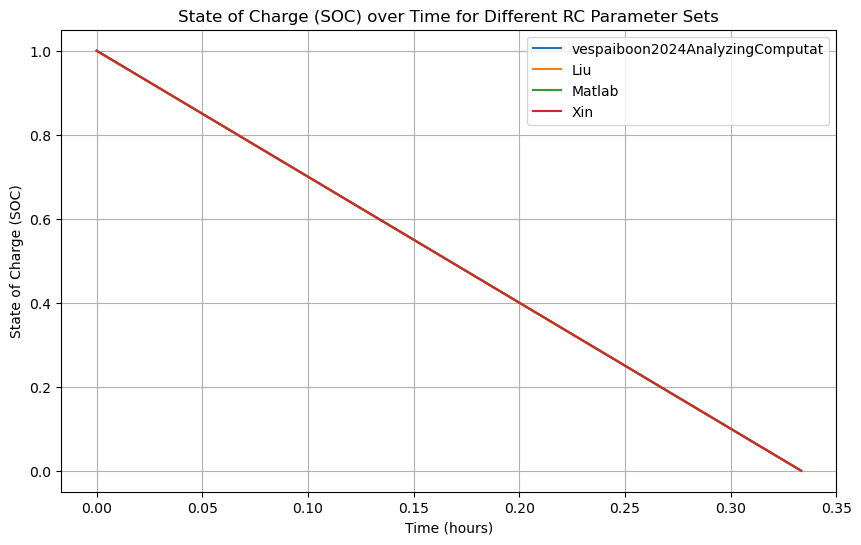

In [113]:
# Plot the soc state of charge over time for each sheet
plt.figure(figsize=(10, 6))
for sheet_name, data in solutions.items():
    plt.plot(data['time'] / 3600, data['SOC'], label=sheet_name)  # Convert time to hours for better readability
plt.xlabel('Time (hours)')
plt.ylabel('State of Charge (SOC)')
plt.title('State of Charge (SOC) over Time for Different RC Parameter Sets')
plt.legend()
plt.grid()
plt.show()

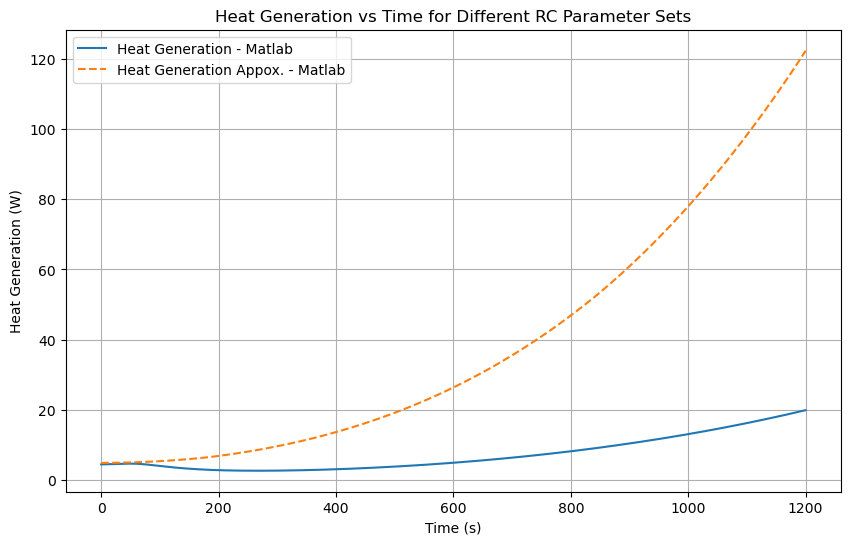

In [114]:
# plot the volumetric heat generation over time for each sheet
plt.figure(figsize=(10, 6))
for sheet_name, data in solutions.items():
    
    # plot the heat generation based on Xin only
    if sheet_name != 'Matlab':
        continue
    
    plt.plot(data['time'], data['heat_generation'], label=f'Heat Generation - {sheet_name}')
    # also plot the heat generation calculated using the fitting function for R_total from [[zhang2024PerformanceInvestigation]] for comparison
    plt.plot(data['time'], data['heat_generation_total'], label=f'Heat Generation Appox. - {sheet_name}', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Heat Generation (W)')
plt.title('Heat Generation vs Time for Different RC Parameter Sets')
plt.grid()
plt.legend()
plt.show()  


ValueError: x and y must have same first dimension, but have shapes (500,) and (1,)

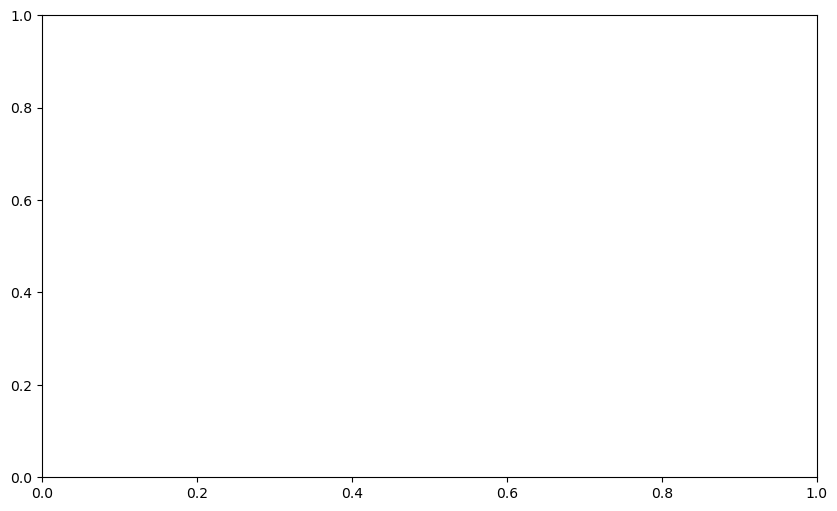

In [111]:
# plot the total resistance over time for each sheet
plt.figure(figsize=(10, 6))
for sheet_name, data in solutions.items(): 
    plt.plot(data['time'], data['R_total'], label=f'Total Resistance - {sheet_name}')
    # also plot the total resistance calculated using the fitting function for R_total from [[zhang2024PerformanceInvestigation]] for comparison
    # plt.plot(data['time'], data['R_total_zhang'], label=f'Total Resistance (Zhang) - {sheet_name}', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Total Resistance (Ohms)')
plt.title('Total Resistance vs Time for Different RC Parameter Sets')
plt.grid()
plt.legend()
plt.show()

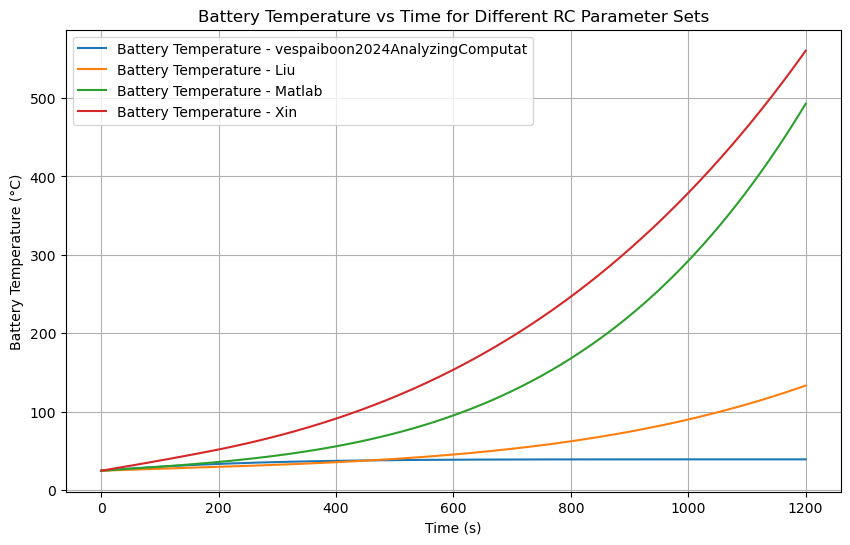

In [71]:
# plot the battery temperature over time for each sheet
plt.figure(figsize=(10, 6))
for sheet_name, data in solutions.items():  
    plt.plot(data['time'], data['T_batt_over_time'], label=f'Battery Temperature - {sheet_name}')
plt.xlabel('Time (s)')
plt.ylabel('Battery Temperature (°C)')
plt.title('Battery Temperature vs Time for Different RC Parameter Sets')
plt.grid()
plt.legend()
plt.show()


Calculating heat generation for SOC at step 1: 0.9899, Time: 12.00 s
Calculating heat generation for SOC at step 2: 0.9798, Time: 24.00 s
Calculating heat generation for SOC at step 3: 0.9697, Time: 36.00 s
Calculating heat generation for SOC at step 4: 0.9596, Time: 48.00 s
Calculating heat generation for SOC at step 5: 0.9495, Time: 60.00 s
Calculating heat generation for SOC at step 6: 0.9394, Time: 72.00 s
Calculating heat generation for SOC at step 7: 0.9293, Time: 84.00 s
Calculating heat generation for SOC at step 8: 0.9192, Time: 96.00 s
Calculating heat generation for SOC at step 9: 0.9091, Time: 108.00 s
Calculating heat generation for SOC at step 10: 0.8990, Time: 120.00 s
Calculating heat generation for SOC at step 11: 0.8889, Time: 132.00 s
Calculating heat generation for SOC at step 12: 0.8788, Time: 144.00 s
Calculating heat generation for SOC at step 13: 0.8687, Time: 156.00 s
Calculating heat generation for SOC at step 14: 0.8586, Time: 168.00 s
Calculating heat genera

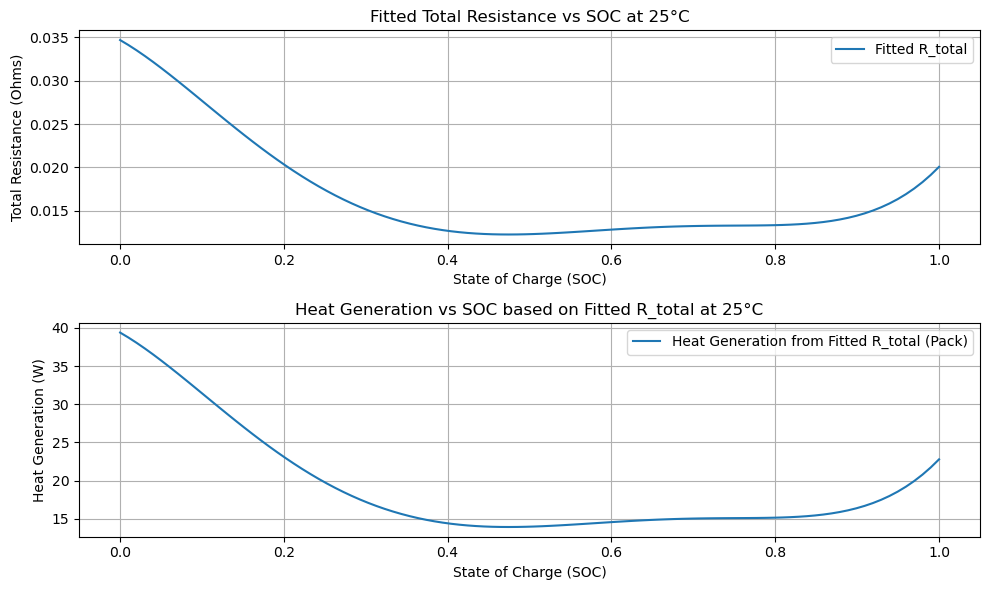

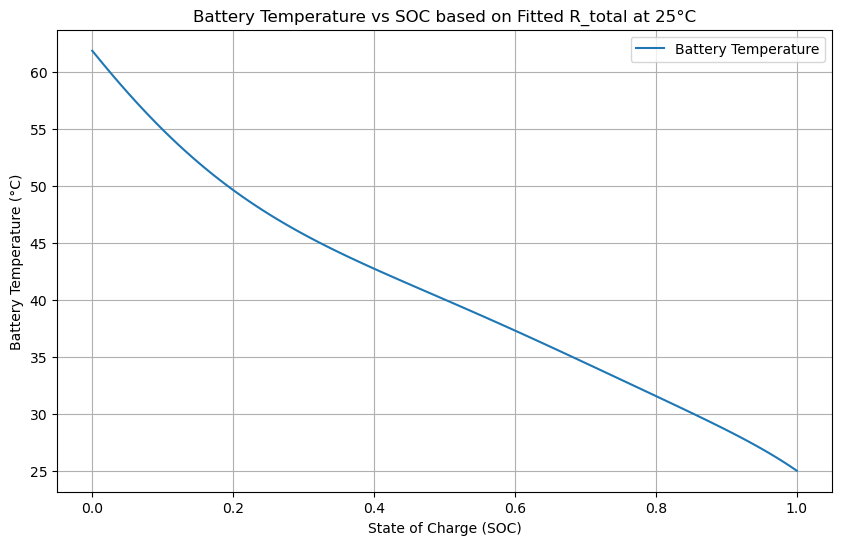

In [102]:
N_batt = 3 * 5 # total number for a 3s by 5p battery pack, found in [[zhang2024PerformanceInvestigation]]

Voc_fitting_params = [    -6.7012999982097625,  
    12.45261134429724,
    -7.487761252473526,
    0.7170105923150693,
    4.093801920808096]

# 估算总时长
discharge_hours = (soc_init - soc_end) / c_rate
t_end = discharge_hours * 3600.0
n_steps = int(np.floor(t_end / dt)) + 1

# 状态初始化
t_arr = np.zeros(n_steps)
soc_arr = np.zeros(n_steps)
T_arr = np.zeros(n_steps)
V1_arr = np.zeros(n_steps)
V2_arr = np.zeros(n_steps)
R0_arr = np.zeros(n_steps)
R1_arr = np.zeros(n_steps)
C1_arr = np.zeros(n_steps)
R2_arr = np.zeros(n_steps)
C2_arr = np.zeros(n_steps)
q_ohmic_arr = np.zeros(n_steps)
q_pol1_arr = np.zeros(n_steps)
q_pol2_arr = np.zeros(n_steps)
q_gen_arr = np.zeros(n_steps)

soc = soc_init
T = t_init_c
V1 = 0.0
V2 = 0.0

soc_list = np.linspace(1, 0, 100)
T_amb = 25.0  # Ambient temperature in Celsius
T_batt_list = [T_amb] # Initialize the battery temperature list with the ambient temperature
R_fitted = R_total_fitting_function(soc_list[0], T_amb)
R_total_fitted = [R_fitted] # Initialize the fitted R_total list with the first value, will be updated in the loop
heat_generation_list = [R_fitted * I_batt**2 * N_batt] # Initialize the heat generation list with zeros, will be updated in the loop
dt = end_time / len(soc_list)  # Time step for the simulation, calculated based on the total simulation time and the number of SOC points


for i in range(1, len(soc_list)):
    print(f"Calculating heat generation for SOC at step {i}: {soc_list[i]:.4f}, Time: {i*dt:.2f} s")
    soc = soc_list[i]
    
    if soc < 0 or soc > 1:
        print(f"Warning: SOC value of {soc:.4f} at index {i} is out of bounds. Clipping to valid range [0, 1].")
        soc = np.clip(soc, 0.0, 1.0)
        soc_list[i] = soc
    
    # Voc = np.polyval(Voc_fitting_params, soc)  # Calculate the open-circuit voltage based on the SOC using the fitting parameters
    
    # # Calculate the partial derivate of Voc with respect to temperature, which is needed for the temperature calculation based on the heat generation
    
    # dVoc_dT = 0.0  
    
    
    T_cur = T_batt_list[i-1]  # Use the battery temperature from the previous time step for the current calculation
    
    R_total = R_total_fitting_function(soc, T_amb)
    R_total_fitted.append(R_total)  # Update the fitted R_total list with the calculated value for the current SOC and temperature
    
    heat_generation = I_batt**2 * R_total
    heat_generation_list.append(heat_generation * N_batt)
    T_cur += heat_generation * dt / (cp_battery * mass_battery)  # Update the current temperature based on the heat generation, time step, specific heat capacity, and mass of the battery
    T_batt_list.append(T_cur) # Assuming T_batt is equal to T_amb for now


# plot the fitted R_total and heat generation
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
# first subplot, plot the fitted R_total vs SOC
plt.plot(soc_list, R_total_fitted, label='Fitted R_total')
plt.xlabel('State of Charge (SOC)')
plt.ylabel('Total Resistance (Ohms)')
plt.title('Fitted Total Resistance vs SOC at 25°C')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
# second subplot, plot the heat generation based on the fitted R_total
plt.plot(soc_list, heat_generation_list, label='Heat Generation from Fitted R_total (Pack)')
plt.xlabel('State of Charge (SOC)')
plt.ylabel('Heat Generation (W)')
plt.title('Heat Generation vs SOC based on Fitted R_total at 25°C')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# plot the battery temperature 
plt.figure(figsize=(10, 6))
plt.plot(soc_list, T_batt_list[:len(soc_list)], label='Battery Temperature')
plt.xlabel('State of Charge (SOC)')
plt.ylabel('Battery Temperature (°C)')
plt.title('Battery Temperature vs SOC based on Fitted R_total at 25°C')
plt.grid()
plt.legend()
plt.show()